# Lanczos Resampling

**Lanczos Resampling** is an advanced image resizing technique that uses sinc functions to perform high-quality interpolation. It is well-known for its ability to produce sharp and smooth images, especially when downscaling. The method utilizes a windowed sinc function to interpolate pixel values, providing better results than Nearest Neighbor, Bilinear, and Bicubic interpolation methods.

## Mathematical Explanation

1. **Original Image and Resizing:**
   - Let $( I )$ be the original image with dimensions $( H \times W )$ (Height × Width).
   - We aim to resize $( I )$ to a new image with dimensions $( H' \times W' )$, where $( H' )$ and $( W' )$ are the new dimensions.

2. **Scaling Factors:**
   - Define scaling factors $( \alpha )$ and $( \beta )$ for the height and width dimensions:
     $$
     \alpha = \frac{H'}{H}
     $$
     $$
     \beta = \frac{W'}{W}
     $$
   - These scaling factors represent how much larger the resized image will be compared to the original image.

3. **Pixel Mapping:**
   - For a pixel at coordinates $( (x', y') )$ in the resized image, calculate the corresponding position in the original image:
     $$
     x = \frac{x'}{\alpha}
     $$
     $$
     y = \frac{y'}{\beta}
     $$
   - $( (x, y) )$ is typically a non-integer value.

4. **Lanczos Interpolation:**
   - Lanczos resampling uses a sinc function windowed by a Lanczos kernel to interpolate pixel values. The sinc function is defined as:
     $$
     \text{sinc}(x) = \frac{\sin(\pi x)}{\pi x}
     $$
   - The Lanczos kernel function $( L(x) )$ is given by:
     $$
     L(x) = \text{sinc}(x) \cdot \text{sinc}\left(\frac{x}{a}\right)
     $$
   - Here, $( a )$ is the number of lobes of the Lanczos kernel (typically set to 2 or 3).

   - To compute the pixel value at $( (x', y') )$, sum the contributions from the surrounding pixels using the Lanczos kernel:
     $$
     I'(x', y') = \sum_{i=-a}^{a} \sum_{j=-a}^{a} L(x - i) \cdot L(y - j) \cdot I(x + i, y + j)
     $$
   - In this formula, $( (x + i, y + j) )$ are the coordinates of the neighboring pixels in the original image.

## Practical Considerations

1. **Quality and Detail:**
   - Lanczos resampling provides high-quality results with sharp details and smooth gradients. It is particularly effective for high-resolution and professional applications.

2. **Computational Complexity:**
   - It is more computationally intensive compared to Nearest Neighbor, Bilinear, and Bicubic methods due to the calculation of the sinc function and its kernel.

3. **Applications:**
   - Commonly used in high-quality image editing, print media, and scenarios where preserving fine details is critical.

## Example Code

Here is a Python code snippet using the `PIL` library to perform Lanczos Resampling for upsampling:

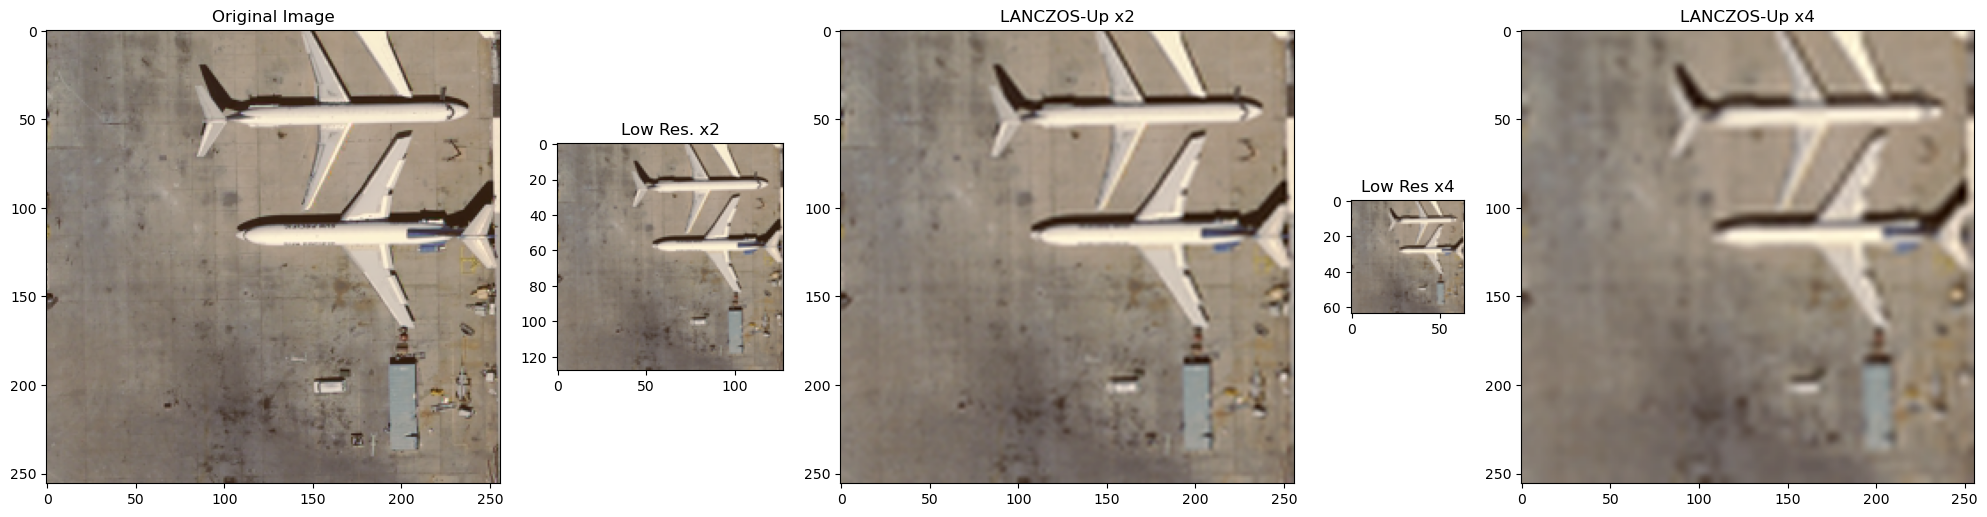

In [1]:
from PIL import Image
import matplotlib.pyplot as plt

def lanczos_upsample(image, scale_factor):
    # Resize the image using Lanczos resampling
    return image.resize(
        (int(image.width * scale_factor), int(image.height * scale_factor)), 
        Image.LANCZOS
    )

# Load an image
image_hr = Image.open('./images/image_hr.png').convert('RGB')
image_lr_2 = Image.open('./images/image_lr_2.png').convert('RGB')
image_lr_4 = Image.open('./images/image_lr_4.png').convert('RGB')

# Perform upsampling with a scale factor of 2
scaled_image_2 = lanczos_upsample(image_lr_2, scale_factor=2)
scaled_image_4 = lanczos_upsample(image_lr_4, scale_factor=4)

# Create a figure with subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 0.5, 1, 0.25, 1]})

# Display each image in a subplot
axs[0].imshow(image_hr)
axs[0].set_title('Original Image')
axs[0].axis('on')

axs[1].imshow(image_lr_2)
axs[1].set_title('Low Res. x2')
axs[1].axis('on')

axs[2].imshow(scaled_image_2)
axs[2].set_title('LANCZOS-Up x2')
axs[2].axis('on')

axs[3].imshow(image_lr_4)
axs[3].set_title('Low Res x4')
axs[3].axis('on')

axs[4].imshow(scaled_image_4)
axs[4].set_title('LANCZOS-Up x4')
axs[4].axis('on')

# Adjust the layout to fit the images properly
plt.tight_layout()
plt.show()